c:\Users\Sunil Kale\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted Salary for Level 6: 145503.1068857161


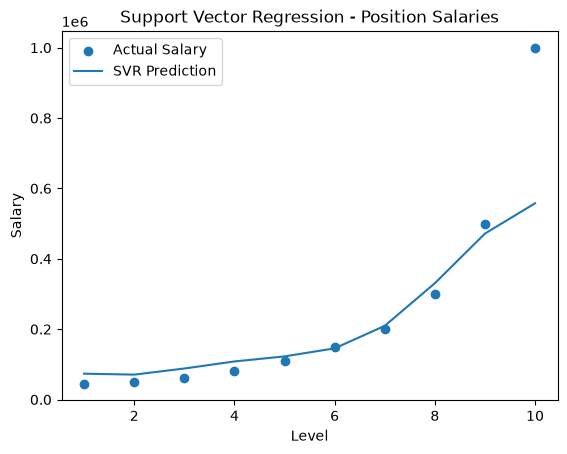

In [1]:
# 7. Implement Support Vector Regression on Salary Dataset
# Dataset: Position_Salaries.csv

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Load dataset
df = pd.read_csv("Position_Salaries.csv")

# Independent variable
X = df[['Level']]

# Target variable
y = df['Salary']

# Feature Scaling
sc_X = StandardScaler()
sc_y = StandardScaler()

X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y.values.reshape(-1, 1)).ravel()

# Create and train SVR model
model = SVR(kernel='rbf')
model.fit(X_scaled, y_scaled)

# Predict salary for Level 6
level = [[6]]

prediction_scaled = model.predict(
    sc_X.transform(level)
)

prediction = sc_y.inverse_transform(
    prediction_scaled.reshape(-1, 1)
)

print("Predicted Salary for Level 6:", prediction[0][0])

# Visualization
plt.scatter(df['Level'], df['Salary'], label="Actual Salary")

plt.plot(
    df['Level'],
    sc_y.inverse_transform(
        model.predict(X_scaled).reshape(-1, 1)
    ),
    label="SVR Prediction"
)

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Support Vector Regression - Position Salaries")
plt.legend()
plt.show()